<a href="https://colab.research.google.com/github/anastasia1615/pythonsybau/blob/main/python_practice_10_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Оцінювання наявності даної роботи буде враховувати як наявність самих візуалізацій (вони можуть незначно відрізнятися від прикладів, але повинні змістовно відображати суть задачі) та опис отриманих вами результатів. При наявності ЛИШЕ візуалізацій без роз'яснень, завдання не буде зараховане за наявне.

Під час виконання вам дозволено користуватися будь-якими зручними для вас Python бібліотеками для візуалізації.

# I. Receiving Data.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. (2б) Для виконання цієї лабораторної роботи Вам необхідно скористатися вибіркою titanic ([train.csv](https://www.kaggle.com/c/titanic/data?select=train.csv)). Зчитайте його та збережіть його у змінну, щоб у подальшому її використати для візуалізацій. Виведіть інформацію про кожну колонку, її індекс, тип та кількість непропущених значень та перші кілька рядків датафрейму.


In [ ]:
df = pd.read_csv("/content/train.csv")
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# IІ. Data Visualization.

2. (10б) Створіть pie chart, який би показував співвідношення виживших до загиблих.

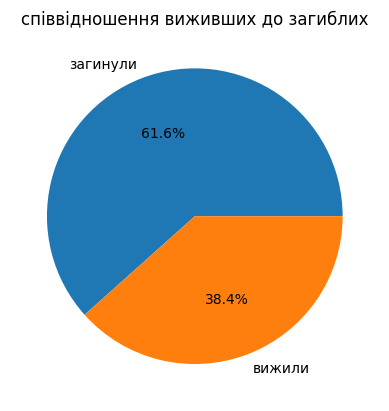

In [ ]:
df['Survived'].value_counts().plot.pie(labels=['загинули', 'вижили'], autopct='%1.1f%%')
plt.title('співвідношення виживших до загиблих')
plt.ylabel('')
plt.show()

у файлі колонка Survived має 2 допустимих значення: 0 (загиблі) або 1 (виживші), за ними і ведеться підрахунок

3. (20б) Створіть bar chart, який би показував співвідношення загиблих до виживших для кожної статі. Для groupby використовуйте атрибут as_index=False.


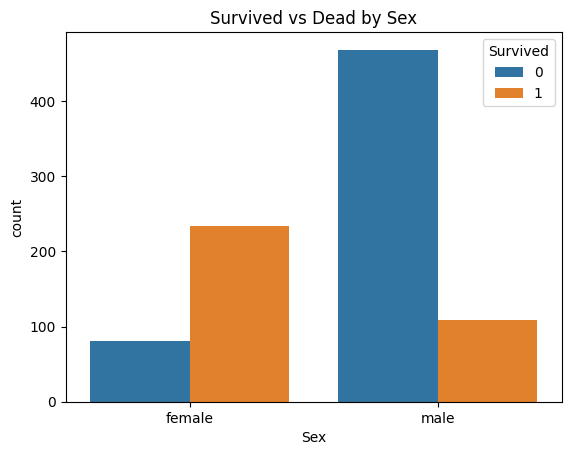

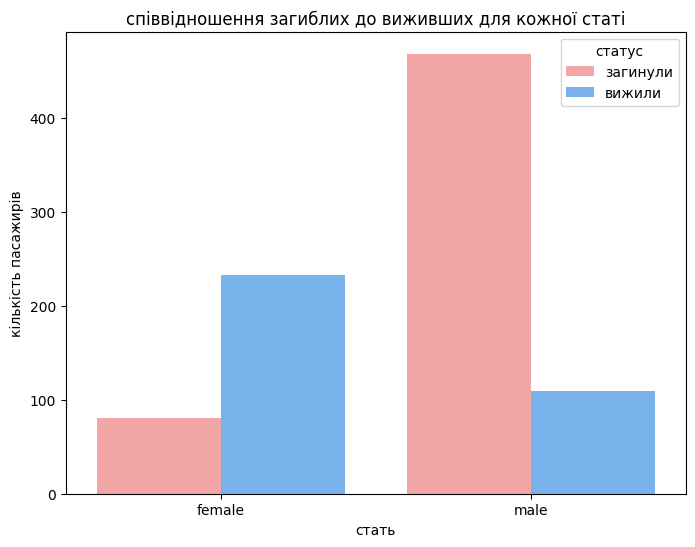

In [ ]:
grouped = df.groupby(['Sex', 'Survived'], as_index=False)['PassengerId'].count()
grouped = grouped.rename(columns={'PassengerId': 'Count'})
plt.figure(figsize=(8, 6))
sns.barplot(data=grouped, x='Sex', y='Count', hue='Survived', palette=['#ff9999','#66b3ff'])
plt.title('співвідношення загиблих до виживших для кожної статі')
plt.xlabel('стать')
plt.ylabel('кількість пасажирів')
handles, _ = plt.gca().get_legend_handles_labels()
plt.legend(handles, ['загинули', 'вижили'], title='статус')
plt.show()

групуємо за статтю і показником "Survived", і ведемо підрахунок

4. (20б) Відобразіть кількість пропущених значень в датасеті по кожній із змінних.

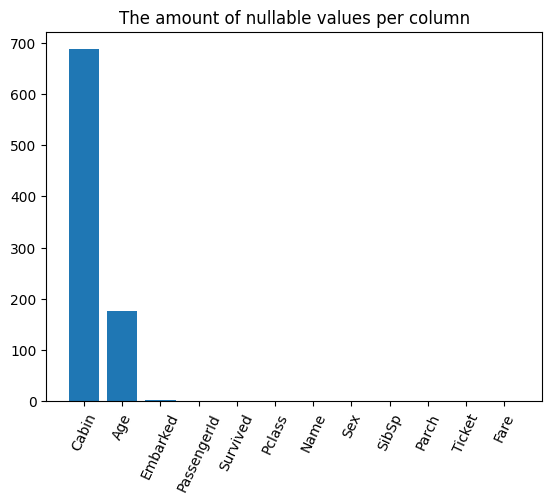

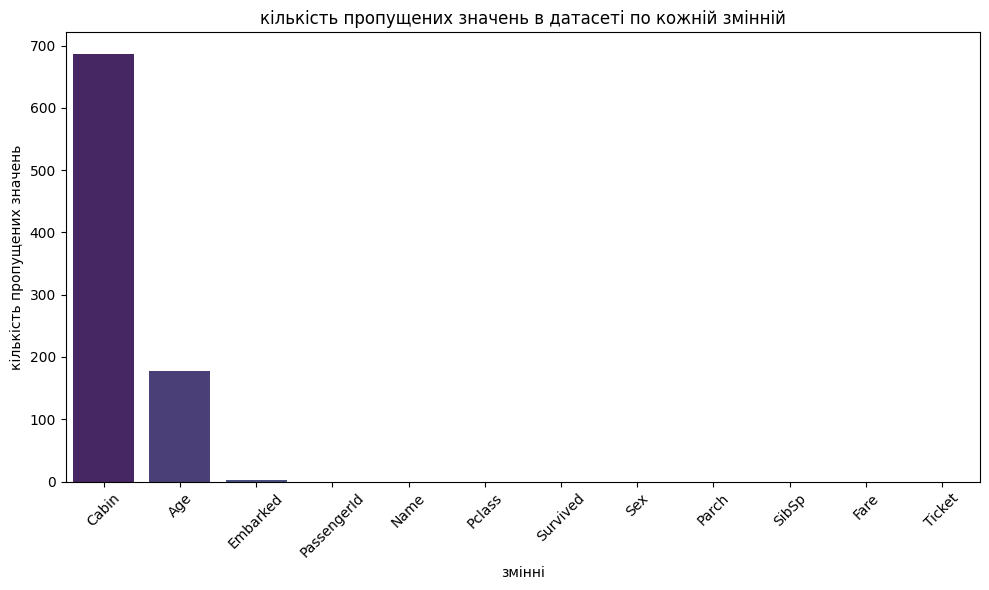

In [13]:
missing_values = df.isnull().sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.index, y=missing_values.values, hue = missing_values.index, palette='viridis', legend = False)
plt.title('кількість пропущених значень в датасеті по кожній змінній')
plt.xlabel('змінні')
plt.ylabel('кількість пропущених значень')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

в кожній колонці датафрейму рахуємо нульові значення, сортуємо стовпчики за спаданням

5. (10б) Побудуйте наступний графік, дайте йому назву та опишіть, що власне на них відображається.

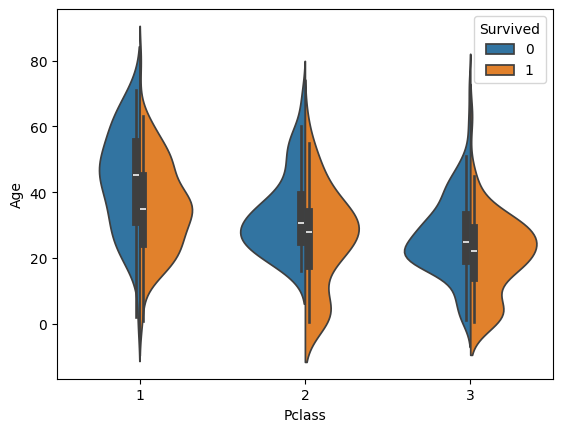

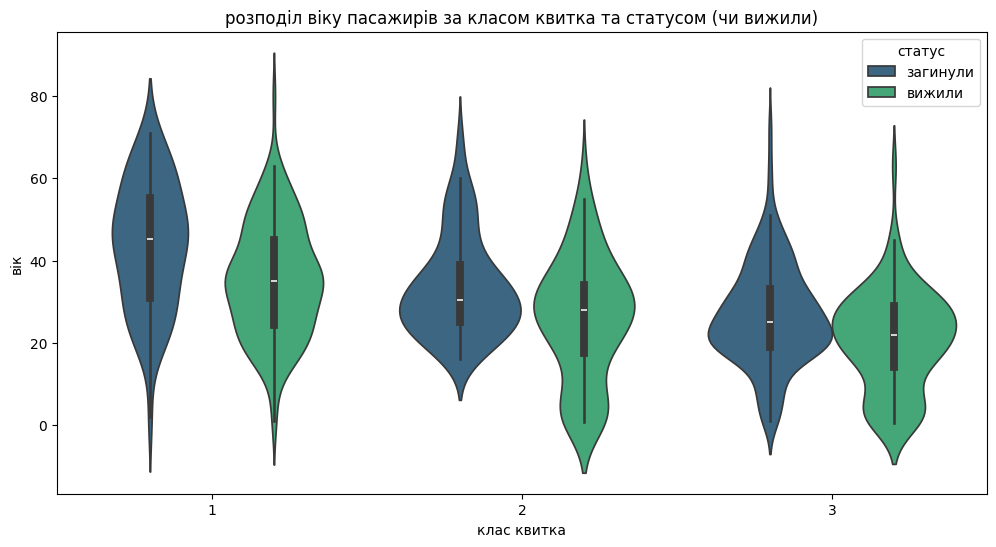

In [15]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='Pclass', y='Age', hue='Survived', palette='viridis')
plt.title('розподіл віку пасажирів за класом квитка та статусом (чи вижили)')
plt.xlabel('клас квитка')
plt.ylabel('вік')
handles, _= plt.gca().get_legend_handles_labels()
plt.legend(handles, ['загинули', 'вижили'], title='статус')
plt.show()

трохи не так як на фото звісно. на графіку - розподіл пасажирів за класом квитка, віком і статусом виживання. чим ширший графік у якійсь точці - тим більше представників даного віку було на борту

6. (13б) Побудуйте графік розподілу частот по віку пасажирів.


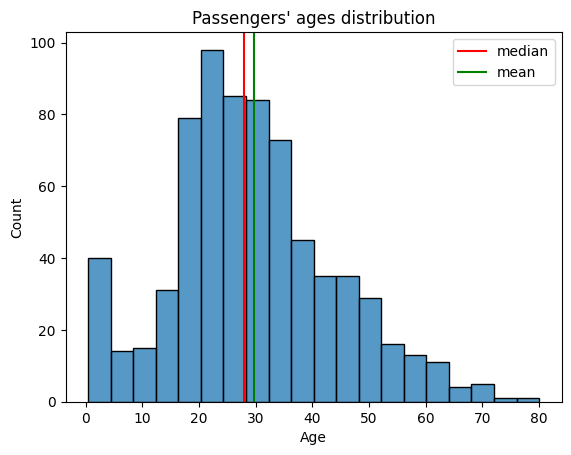

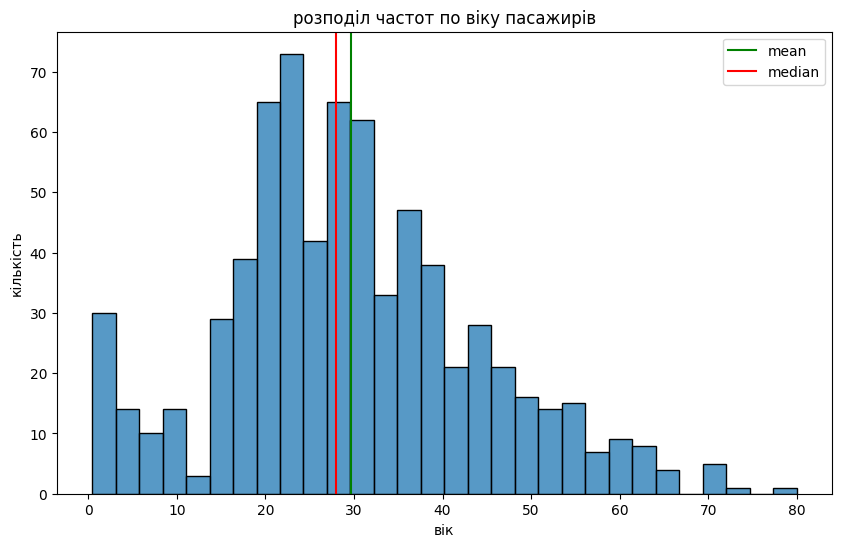

In [22]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Age', bins=30, kde=False)
mean_age = df['Age'].mean()
median_age = df['Age'].median()
plt.axvline(mean_age, color='green', label='mean')
plt.axvline(median_age, color='red', label='median')
plt.title('розподіл частот по віку пасажирів')
plt.xlabel('вік')
plt.ylabel('кількість')
plt.legend()
plt.show()

на цьому графіку зображена частота, з якою зустрічались пасажири даного віку. дві лінії, червона - медіана, зелена - середнє арифметичне

7. (25б) Поставте бізнес-питання до даних. Дайте на нього відповідь за допомогою візуалізацій. Прокоментуйте отриману відповідь.

як впливав розмір сім'ї пасажира на його шанси вижити?

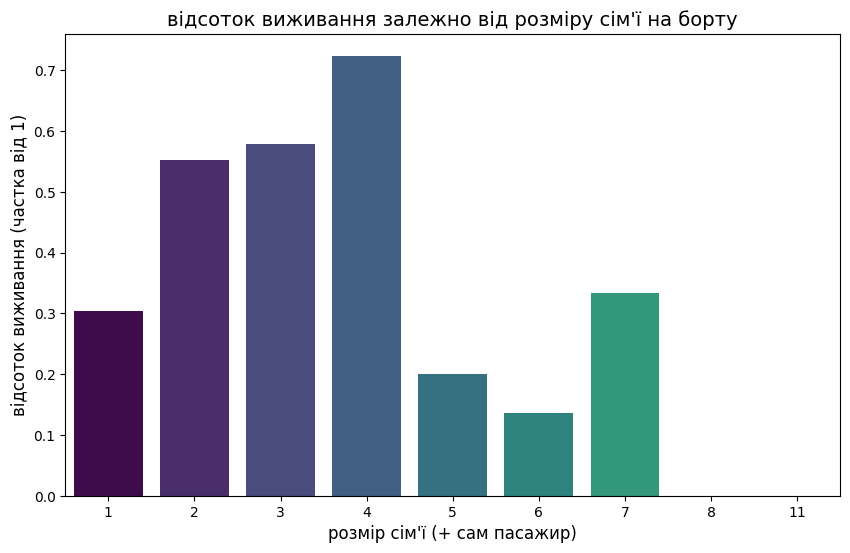

In [30]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1 #нова колонка = кількість братів/сестер, батьків і сам пасажир
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='FamilySize', y = 'Survived', hue = 'FamilySize', palette='viridis',errorbar=None, legend = False)
plt.title("відсоток виживання залежно від розміру сім'ї на борту", fontsize=14)
plt.xlabel("розмір сім'ї (+ сам пасажир)", fontsize=12)
plt.ylabel("відсоток виживання (частка від 1)", fontsize=12)
plt.show()

створили нову колонку, в якій рахуються всі, хто був супутником пасажира, так і рахували розмір сім'ї. на статистиці бачимо, що сім'ї з 4 людей мали найбільший шанс вижити

# Вітаю! Ви велика(ий) молодець, що впоралась(вся). Похваліть себе та побалуйте чимось приємним. Я Вами пишаюся.

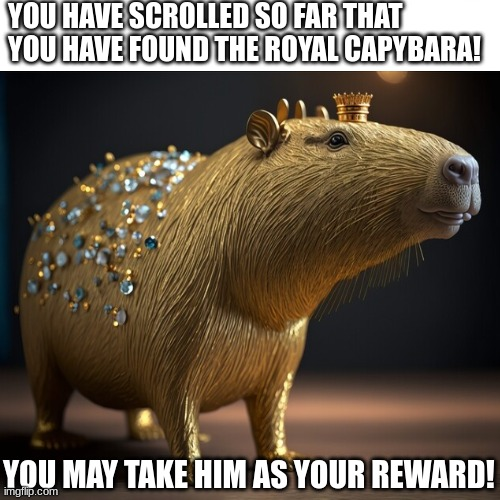